In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn, Tensor
from sklearn.datasets import make_moons
from sklearn.datasets import make_swiss_roll

from flow_matching.solver import ODESolver 
from flow_matching.utils import ModelWrapper 

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


In [3]:
class FlowModel(nn.Module):
    def __init__(self, dim=2, h=256):
        super().__init__()
        # self.net = nn.Sequential(
        #     nn.Linear(dim + 1, h),
        #     nn.SiLU(),
        #     nn.Linear(h, h),
        #     nn.SiLU(),
        #     nn.Linear(h, h),
        #     nn.SiLU(),
        #     nn.Linear(h, h),
        #     nn.SiLU(),
        #     nn.Linear(h, dim)
        # )

        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        t = t.expand(*x.shape[:-1], 1) if t.dim() == 0 else t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), dim=-1))

velocity_model = FlowModel()
velocity_model.to(device)


FlowModel(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=256, out_features=2, bias=True)
  )
)

#### Dataset

Data shape: (5000, 2)


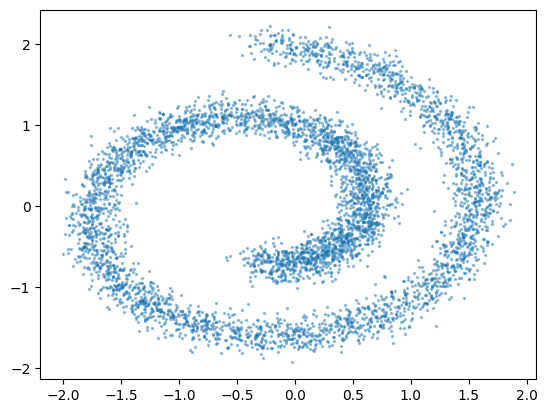

In [4]:
def get_data_batch(batch_size: int, noise: float = 0.8) -> Tensor:
    return Tensor(make_swiss_roll(batch_size, noise=noise)[0][:, [0, 2]])

X = get_data_batch(5000)
X = (X - X.mean(dim=0)) / X.std(dim=0)
X = X.numpy()
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.4)

print("Data shape:", X.shape)

#### Training

In [5]:
N_SAMPLES = 512
NOISE = 0.8

# # Precompute normalization stats from a large reference batch
# _x_ref = Tensor(make_swiss_roll(5000, noise=NOISE)[0][:, [0, 2]])
# mean_x1 = _x_ref.mean(dim=0)
# std_x1 = _x_ref.std(dim=0)

# Initialize model
velocity_model = FlowModel()
velocity_model.to(device)

optimizer = torch.optim.Adam(velocity_model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
losses = []

for i in range(20000):
    x_1 = Tensor(make_swiss_roll(N_SAMPLES, noise=NOISE)[0][:, [0, 2]]).to(device)
    # x_1 = (x_1 - mean_x1) / std_x1
    x_0 = torch.randn_like(x_1).to(device)
    t = torch.rand(len(x_1), 1).to(device)

    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0

    optimizer.zero_grad()
    loss = loss_fn(velocity_model(t=t, x=x_t), dx_t)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if i % 2000 == 0:
        print(f"Step {i}, Loss: {loss.item():.4f}")


Step 0, Loss: 53.0064
Step 2000, Loss: 9.8006
Step 4000, Loss: 10.9000
Step 6000, Loss: 10.9101
Step 8000, Loss: 10.6643
Step 10000, Loss: 10.9050
Step 12000, Loss: 8.5436
Step 14000, Loss: 9.2932
Step 16000, Loss: 11.9704
Step 18000, Loss: 9.1378


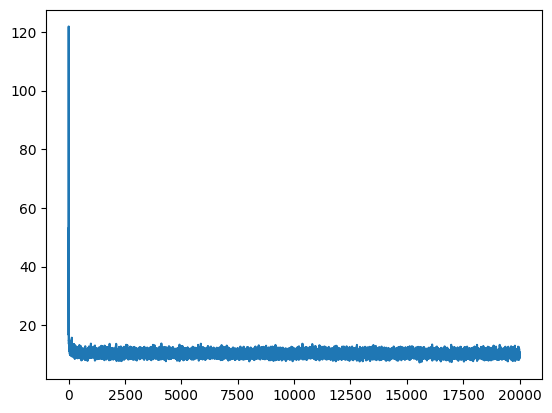

In [6]:
plt.plot(losses)

#### Sampling

In [7]:
X.shape

(5000, 2)

In [8]:
BATCH_SIZE = 256
x_0 = torch.randn(BATCH_SIZE, X.shape[-1]) # Specify the initial condition 

print("x_0 shape:", x_0.shape)

x_0 shape: torch.Size([256, 2])


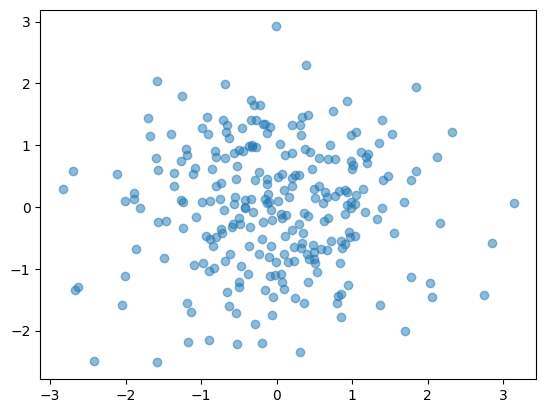

In [9]:
plt.plot(x_0[:, 0].numpy(), x_0[:, 1].numpy(), 'o', alpha=0.5, label='Initial Points')

In [12]:
NUM_STEPS = 100

solver = ODESolver(velocity_model=velocity_model.cpu()) 
# x_1 = solver.sample(x_init=x_0, method='midpoint', step_size=1.0 / NUM_STEPS)

T = torch.linspace(0, 1, 10)
x_1 = solver.sample(time_grid=T, 
                    x_init=x_0, 
                    method='midpoint', 
                    step_size=1.0/NUM_STEPS, 
                    return_intermediates=True)  # sample from the model

print("x_1 shape:", x_1.shape)

x_1 shape: torch.Size([10, 256, 2])


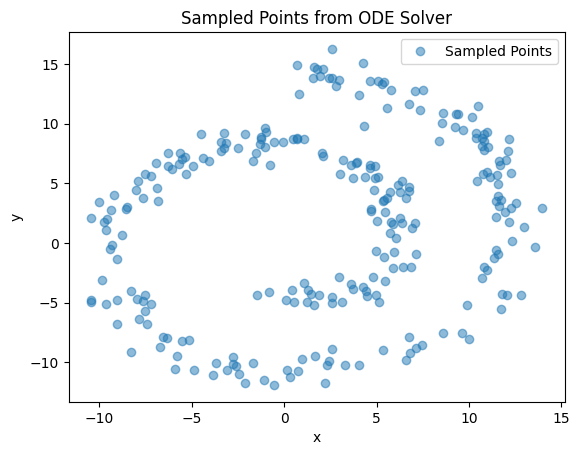

x_1 shape: torch.Size([10, 256, 2])


In [13]:
plt.plot(x_1[-1, :, 0].numpy(), x_1[-1, :, 1].numpy(), 'o', alpha=0.5, label='Sampled Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sampled Points from ODE Solver')
plt.legend()
plt.show()

print("x_1 shape:", x_1.shape)

Samples shape: (10, 256, 2)


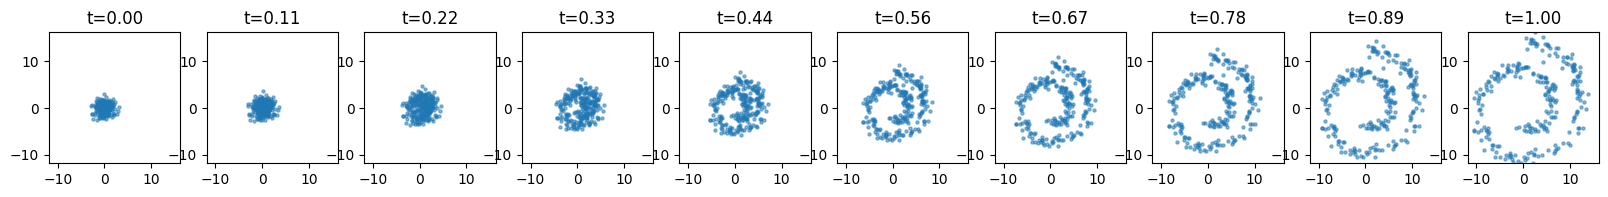

In [19]:
NUM_STEPS = 10
STEP_SIZE = 0.01

solver = ODESolver(velocity_model=velocity_model) 

T = torch.linspace(0, 1, NUM_STEPS) 
sol = solver.sample(
    time_grid=T, 
    x_init=x_0, 
    method='midpoint', 
    step_size=STEP_SIZE, 
    return_intermediates=True,
)  # sample from the model

# - Plot samples
samples = sol.numpy()
print("Samples shape:", samples.shape)

x_min, x_max = samples.min(), samples.max()
_, axs = plt.subplots(1, NUM_STEPS, figsize=(20, 3.2))

for i in range(NUM_STEPS):
    axs[i].scatter(samples[i, :, 0], samples[i, :, 1], s=5, alpha=0.5)
    axs[i].set_title(f"t={T[i].item():.2f}")
    axs[i].set_xlim(x_min, x_max)
    axs[i].set_ylim(x_min, x_max)
    axs[i].set_aspect('equal')

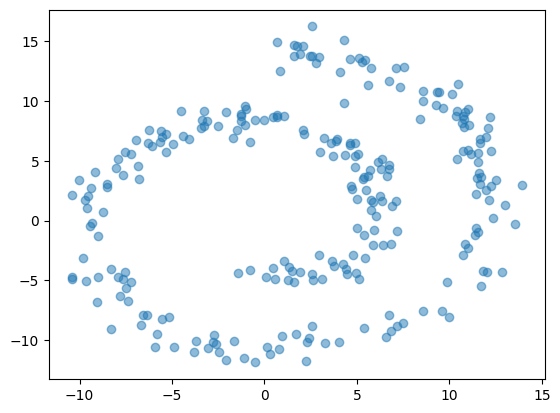

In [16]:
plt.plot(samples[-1, :, 0], samples[-1, :, 1], 'o', alpha=0.5, label='Final Sampled Points')